In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с изображением

In [2]:
image = cv2.imread('sar_2_color.jpg')

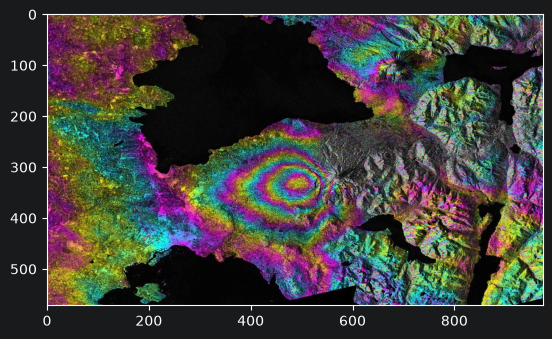

In [3]:
plt.imshow(image)

In [4]:
image.shape # h,w,c

(572, 974, 3)

In [5]:
image[250,250] # b,g,r

array([12, 12, 12], dtype=uint8)

In [6]:
# ROI
img_roi = image[100:200, 500:700]

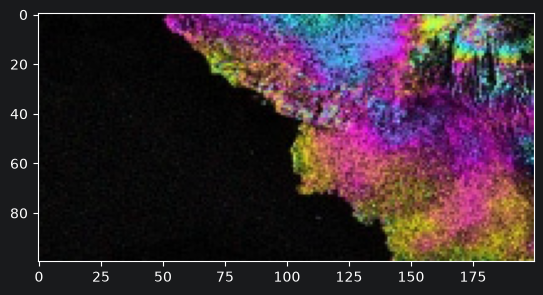

In [7]:
plt.imshow(img_roi)

In [8]:
b,g,r = cv2.split(image)

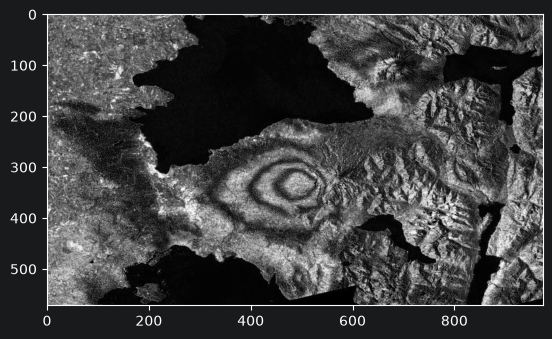

In [9]:
plt.imshow(b, cmap = 'gray')

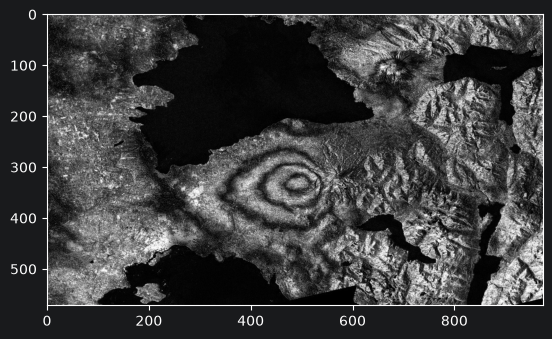

In [10]:
plt.imshow(g, cmap = 'gray')

In [11]:
# alternative approach
b = image[:,:,0]

In [12]:
import copy

image2 = copy.deepcopy(image)

In [13]:
image2[50:100,50:100] = [0,0,0]

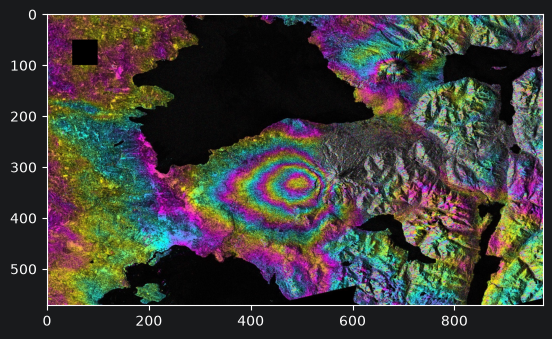

In [14]:
plt.imshow(image2)

In [15]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

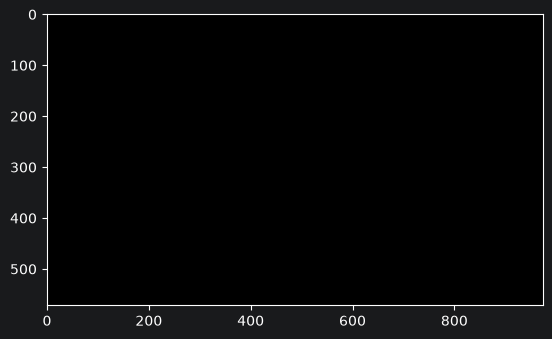

In [16]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [17]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [18]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

In [19]:
image_gray[0,0]

np.uint8(40)

In [20]:
image_gray.shape

(572, 974)

In [21]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [22]:
image_hsv.shape

(572, 974, 3)

In [23]:
image_hsv[0,0]

array([117, 143,  75], dtype=uint8)

In [24]:
image[0,0]

array([75, 37, 33], dtype=uint8)

In [25]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [26]:
image_lab[0,0]

array([ 42, 139, 104], dtype=uint8)

# Пороговая фильтрация

In [27]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

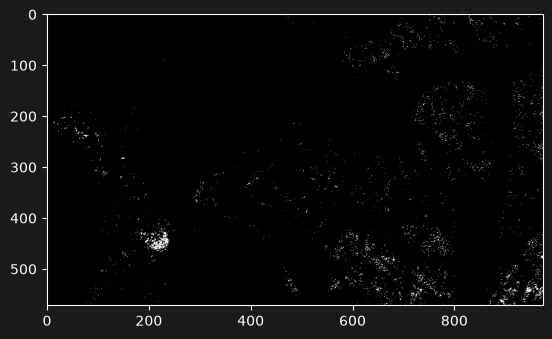

In [28]:
plt.imshow(thresh1, cmap='gray')

In [29]:
thresh1[thresh1==100].sum()

np.uint64(0)

# Построение гистограммы

In [30]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

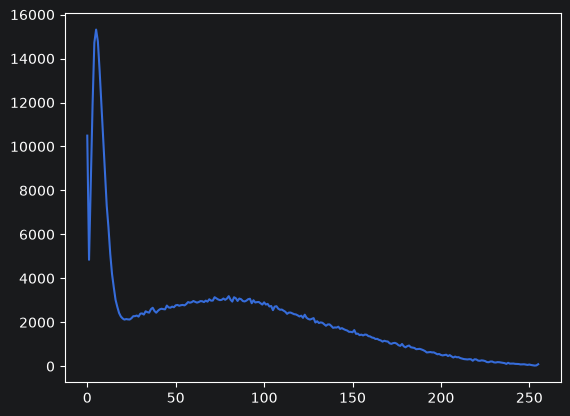

In [32]:
plt.plot(b_hist)

In [33]:
b_hist_cum = b_hist.cumsum()

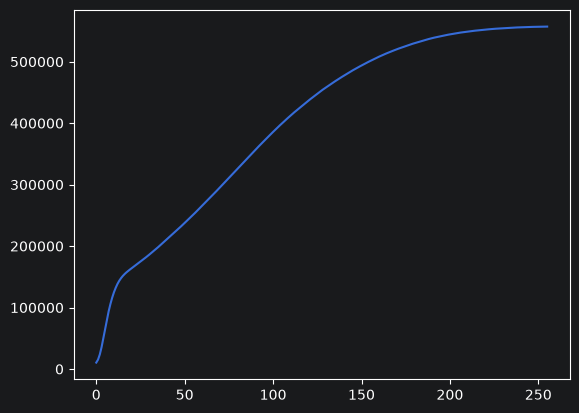

In [34]:
plt.plot(b_hist_cum)

In [35]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

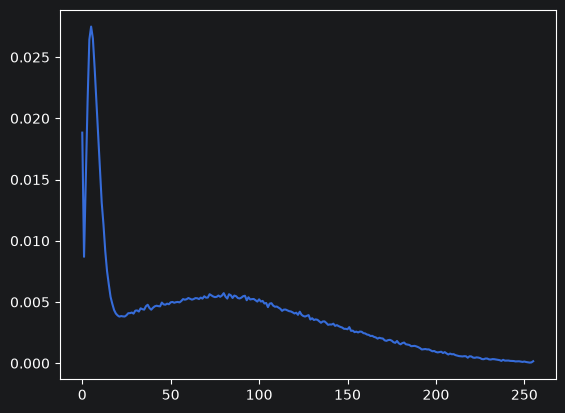

In [36]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [37]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 1.0


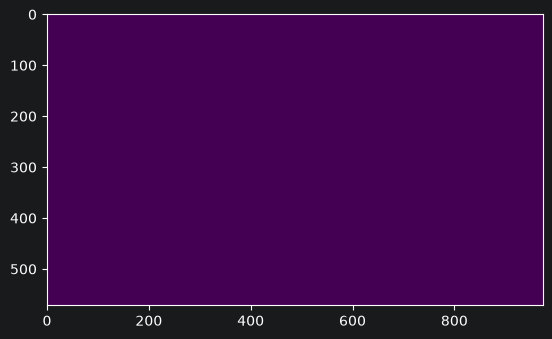

In [38]:
plt.imshow(diff)

In [39]:
mse = mean_squared_error(image_gray, image_gray)
mse

np.float64(0.0)

# Статистические характеристики изображений

In [40]:
mean = image_gray.mean()

In [41]:
std = image_gray.std()

In [42]:
print(mean,std)

67.41225535245043 52.01619187595963


In [43]:
eq_gray = cv2.equalizeHist(image_gray)

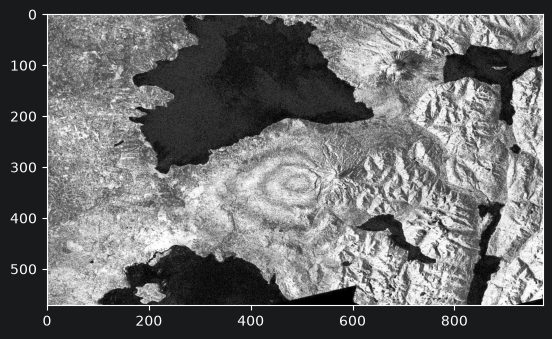

In [44]:
plt.imshow(eq_gray, cmap="gray")


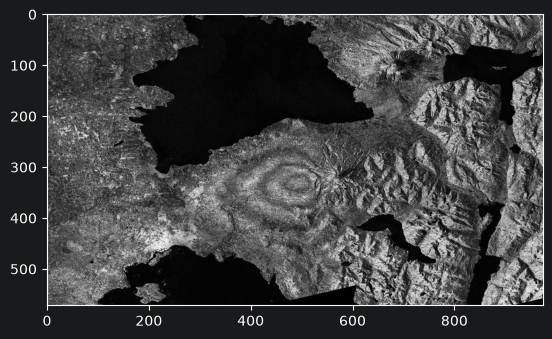

In [45]:
plt.imshow(image_gray, cmap="gray")

In [ ]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


(400, 600)


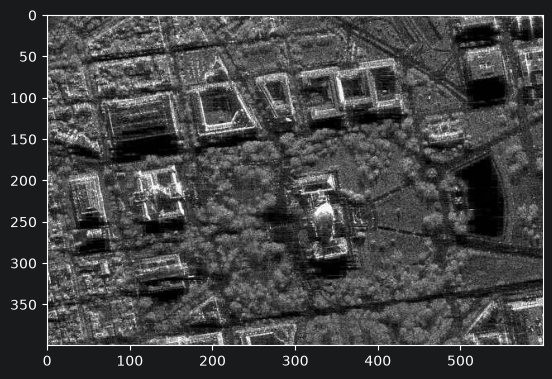

In [46]:
sar_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

print(sar_gray.shape)
plt.imshow(sar_gray, cmap='gray')

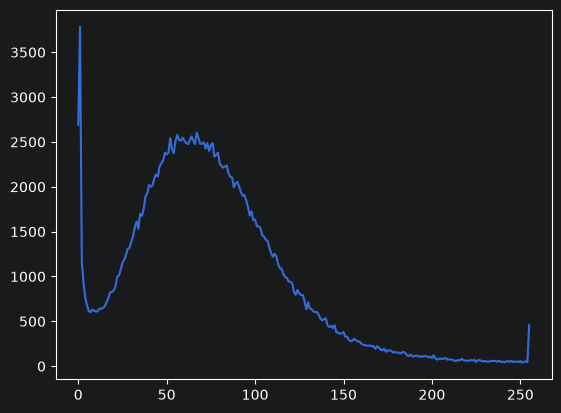

In [47]:
hist = cv2.calcHist([sar_gray], [0], None, [256], [0, 256])

plt.plot(hist)
plt.show()

In [48]:
def gamma_correction(image, gamma):
    normalized = image / 255.0
    corrected = np.power(normalized, gamma)
    return np.uint8(corrected * 255)

gamma_less = gamma_correction(sar_gray, 0.5)
gamma_more = gamma_correction(sar_gray, 2.0)

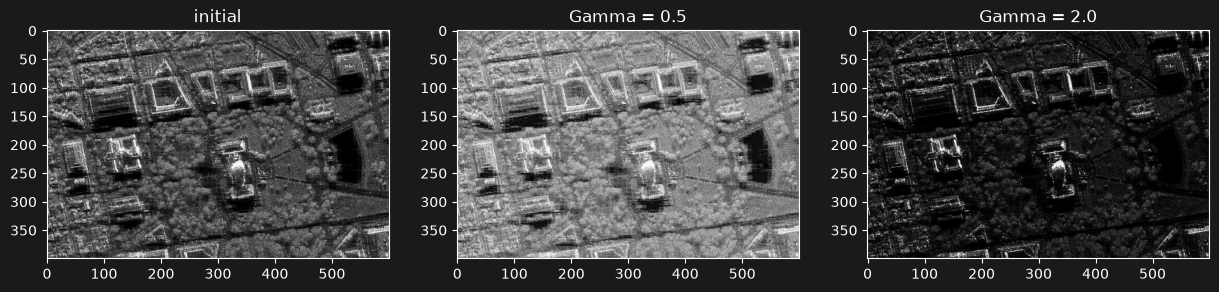

In [49]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sar_gray, cmap='gray')
plt.title('initial')

plt.subplot(1, 3, 2)
plt.imshow(gamma_less, cmap='gray')
plt.title('Gamma = 0.5')

plt.subplot(1, 3, 3)
plt.imshow(gamma_more, cmap='gray')
plt.title('Gamma = 2.0')

plt.show()

In [50]:
mse_less = mean_squared_error(sar_gray, gamma_less)
ssim_less = structural_similarity(sar_gray, gamma_less)

mse_more = mean_squared_error(sar_gray, gamma_more)
ssim_more = structural_similarity(sar_gray, gamma_more)

print("Gamma = 0.5: MSE =", mse_less, "SSIM =", ssim_less)
print("Gamma = 2.0: MSE =", mse_more, "SSIM =", ssim_more)

Gamma = 0.5: MSE = 3250.429145833333 SSIM = 0.7875008686792752
Gamma = 2.0: MSE = 2383.7636375 SSIM = 0.5270459922820343


In [51]:
eq_gray = cv2.equalizeHist(image_gray)

In [52]:
mean_src = sar_gray.mean()
std_src = sar_gray.std()

mean_ref = eq_gray.mean()
std_ref = eq_gray.std()

print(mean_src, std_src)
print(mean_ref, std_ref)

74.94157083333333 43.658465466227916
127.64575286110194 73.46412531208956


In [53]:
corrected = (sar_gray.astype(np.float32) - mean_src) / std_src
corrected = corrected * std_ref + mean_ref

corrected = np.clip(corrected, 0, 255).astype(np.uint8)

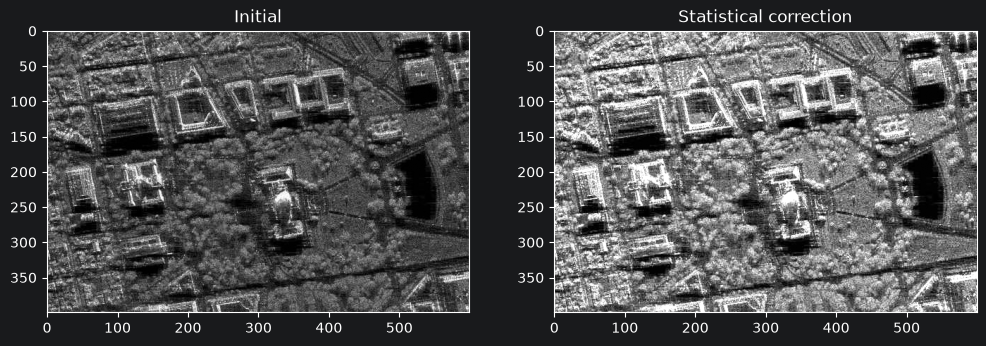

In [54]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(sar_gray, cmap='gray')
plt.title('Initial')

plt.subplot(1, 2, 2)
plt.imshow(corrected, cmap='gray')
plt.title('Statistical correction')

plt.show()

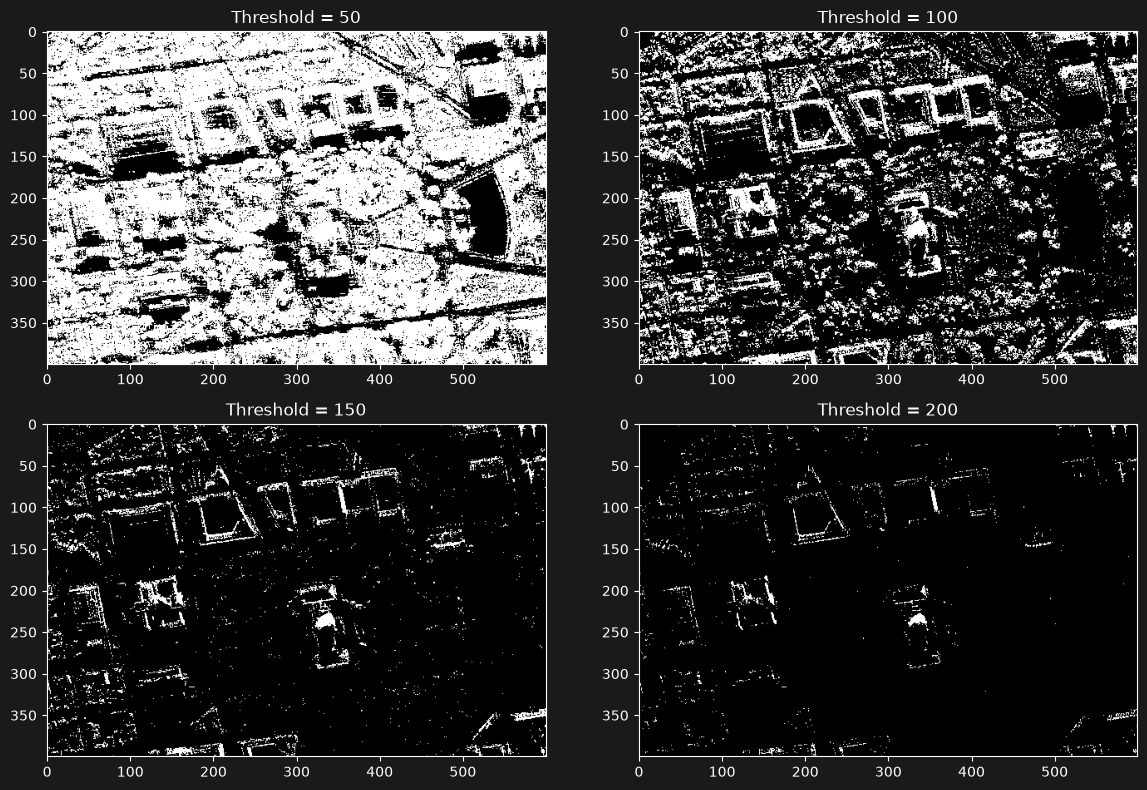

In [55]:
thresholds = [50, 100, 150, 200]

plt.figure(figsize=(12, 8))

for i, t in enumerate(thresholds):
    _, thresh = cv2.threshold(sar_gray, t, 255, cv2.THRESH_BINARY)

    plt.subplot(2, 2, i + 1)
    plt.imshow(thresh, cmap='gray')
    plt.title(f'Threshold = {t}')

plt.tight_layout()
plt.show()

In [56]:
for t in thresholds:
    _, thresh = cv2.threshold(sar_gray, t, 255, cv2.THRESH_BINARY)
    print("Threshold =", t, "White pixels =", np.sum(thresh == 255))

Threshold = 50 White pixels = 169178
Threshold = 100 White pixels = 55653
Threshold = 150 White pixels = 13083
Threshold = 200 White pixels = 3830
